###  Dataset 2: Predicción de aprobación de préstamos
https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

### Variable objetivo (target)

Loan_Status: indica si el préstamo fue aprobado o no. Lo cual lo convierte en un problema de clasificación, dado que la variable que queremos predecir no es un numero continuo sino una categoria con dos posibles valores. 

### Contexto.

Una entidad financiera recibe solicitudes de crédito hipotecario. Cada solicitante aporta datos como género, estado civil, número de dependientes, nivel educativo, si es independiente, sus ingresos, el monto solicitado, el plazo del préstamo, su historial crediticio y el tipo de zona de la propiedad. Con base en solicitudes históricas de las cuales ya se conoce si fueron aprobadas o no, el banco quiere construir un modelo que le ayude a predecir automáticamente si una nueva solicitud será aprobada, agilizando el proceso de decisión.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

#cargamos el dataset de entrenamiento

loan_data = pd.read_csv('train.csv ')

loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
#Verificamos cuantas filas y columnas tiene el dataset
print("Filas y columnas:\n", loan_data.shape, "\n")








Filas y columnas:
 (614, 13) 



In [3]:
#verificamos tipos de datos de cada columna
print("Tipos de datos:\n", loan_data.dtypes, "\n")

Tipos de datos:
 Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object 



In [4]:
# y por ultimo verificamos si hay valores nulos en el dataset
print("Valores nulos:\n", loan_data.isnull().sum(), "\n")

Valores nulos:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64 



C:\Users\JJ_16\AppData\Local\Temp\ipykernel_18008\378435288.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Loan_Status', data=loan_data, palette='Set2')


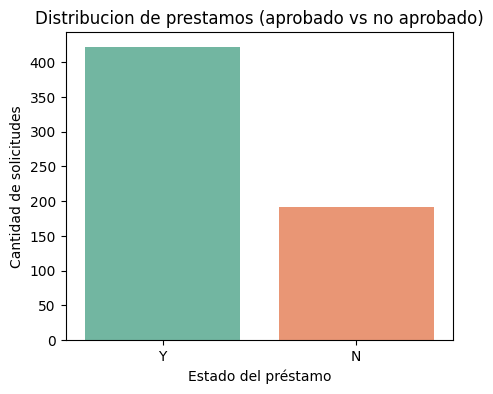

In [5]:
#grafico de barras para ver la distribucion de prestamos aprobados y no aprobados
plt.figure(figsize=(5,4))
sns.countplot(x='Loan_Status', data=loan_data, palette='Set2')
plt.title('Distribucion de prestamos (aprobado vs no aprobado)')
plt.xlabel('Estado del préstamo')
plt.ylabel('Cantidad de solicitudes')
plt.show()

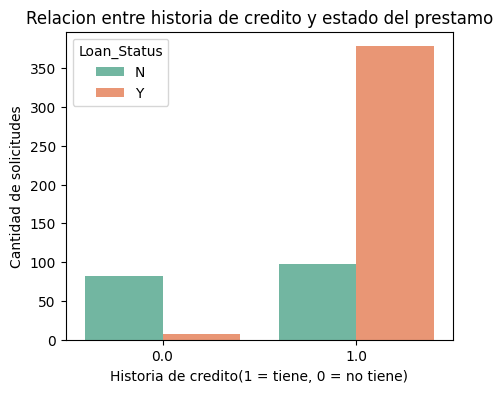

In [6]:
#grafico de relacion entre historia de credito y estado del prestamo
plt.figure(figsize=(5,4))
sns.countplot(x='Credit_History', hue='Loan_Status', data=loan_data, palette='Set2')
plt.title('Relacion entre historia de credito y estado del prestamo')
plt.xlabel('Historia de credito(1 = tiene, 0 = no tiene)')
plt.ylabel('Cantidad de solicitudes')
plt.show()

Este grafico de relacion nos indica que la mayoria de rechazos ocurren en el grupo de credit_history = 0. Que podria indicarnos que esta sería una de las variables mas importantes para el modelo.

#### Exploración de datos.

In [7]:
# Variables numericas rellenadas con la mediana que es menos sensible a los valores atipicos
loan_data['LoanAmount']= loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())
loan_data['Loan_Amount_Term']= loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].median())
loan_data['Credit_History']= loan_data['Credit_History'].fillna(loan_data['Credit_History'].mode()[0]) #Para esta variable se usa la moda ya que es una variable categorica, tiene mas sentido.

In [8]:
#Variables categoricas rellenadas con la moda que es el valor mas frecuente
loan_data['Gender']= loan_data['Gender'].fillna(loan_data['Gender'].mode()[0])
loan_data['Married']= loan_data['Married'].fillna(loan_data['Married'].mode()[0])
loan_data['Dependents']= loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0])
loan_data['Self_Employed']= loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0])

In [9]:
# Verificamos que ya no queden nulos
print(loan_data.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [10]:
#Una copia del dataset para trabajar con el modelo de prediccion y no modificar el dataset original
loan_model = loan_data.copy()

In [11]:
#eliminamos la columna Loan_ID ya que no es relevante para el modelo de prediccion
loan_model.drop('Loan_ID', axis=1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [12]:
#codificamos las variables categoricas a numericas para poder trabajar con el modelo de prediccion
label_encoder = LabelEncoder() #asigna un numero entero a cada categoria unica.

columns_to_encode = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for column in columns_to_encode:
    loan_model[column] = label_encoder.fit_transform(loan_model[column])

loan_model.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [13]:
# asignamos a X todas las columnas menos la columna Loan_Status que es la que queremos predecir
X = loan_model.drop(['Loan_Status', 'Loan_ID'], axis=1) #Agregue 'Loan_ID' a la lista de columnas a eliminar para que no esté en X, ya que no es relevante para el modelo de predicción. Y parece que no se elimino antes.

#asignamos a Y la columna Loan_Status que es la que queremos predecir
Y = loan_model['Loan_Status']

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("X columns:", list(X.columns))

X shape: (614, 11)
Y shape: (614,)
X columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


### X contiene todas las variables que el modelo va a usar para aprender a predecir.
### Y contiene solo la respuesta correcta que el modelo debe aprender a predecir.

In [14]:
#dividir el dataset en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,  # 20% para prueba
    random_state=42,  # para que la division sea reproducible
    stratify=Y  # para mantener la proporción de clases en ambos conjuntos
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (491, 11)
Tamaño de prueba: (123, 11)


In [15]:
#escalamos las variables para que esten en rangos comparables.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de regresion logistica
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, Y_train)

##predicciones del modelo de regresion logistica
Y_pred_lr = lr_model.predict(X_test_scaled)

print("Primeras 10 predicciones:\n", Y_pred_lr[:10])
print("Primeros 10 valores reales:\n", Y_test[:10].values)

Primeras 10 predicciones:
 [0 1 1 1 1 1 1 1 1 1]
Primeros 10 valores reales:
 [0 1 1 1 1 0 1 1 1 1]


In [16]:
# arbol de decision
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, Y_train)

#predicciones del modelo de arbol de decision en el conjunto de prueba
Y_pred_dt = dt_model.predict(X_test_scaled)

print("Primeras 10 predicciones del arbol de decision:\n", Y_pred_dt[:10])
print("Primeros 10 valores reales:\n", Y_test[:10].values)

Primeras 10 predicciones del arbol de decision:
 [0 1 1 1 1 1 1 1 1 1]
Primeros 10 valores reales:
 [0 1 1 1 1 0 1 1 1 1]


Nota para mi: El Árbol de Decisión funciona muy distinto a la regresión logística. En vez de calcular pesos y probabilidades matemáticamente hablando, hace una serie de preguntas tipo sí/no sobre las variables, como un diagrama de flujo.

Accurracy: 0.8617886178861789
Precisión: 0.84
Recall: 0.9882352941176471
F1-Score: 0.9081081081081082


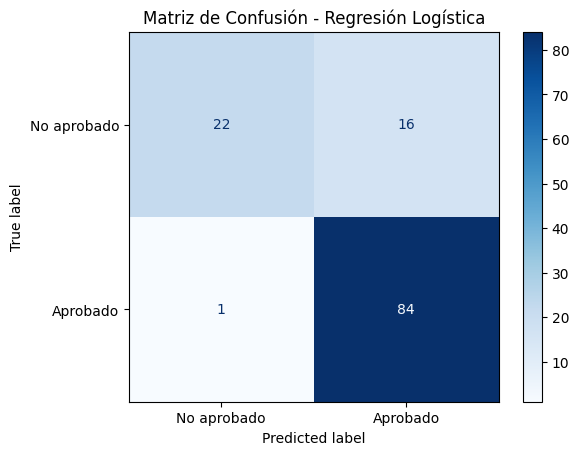

In [17]:
# Evaluamos el modelo de regresion logistica
accuracy_lr = accuracy_score(Y_test, Y_pred_lr)
precision_lr = precision_score(Y_test, Y_pred_lr)
recall_lr = recall_score(Y_test, Y_pred_lr)
f1_lr = f1_score(Y_test, Y_pred_lr)

print("Accurracy:", accuracy_lr)
print("Precisión:", precision_lr)
print("Recall:", recall_lr)
print("F1-Score:", f1_lr)

cm_lr = confusion_matrix(Y_test, Y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No aprobado','Aprobado'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

=== Árbol de Decisión ===
Accuracy:  0.8211382113821138
Precision: 0.8247422680412371
Recall:    0.9411764705882353
F1-score:  0.8791208791208791


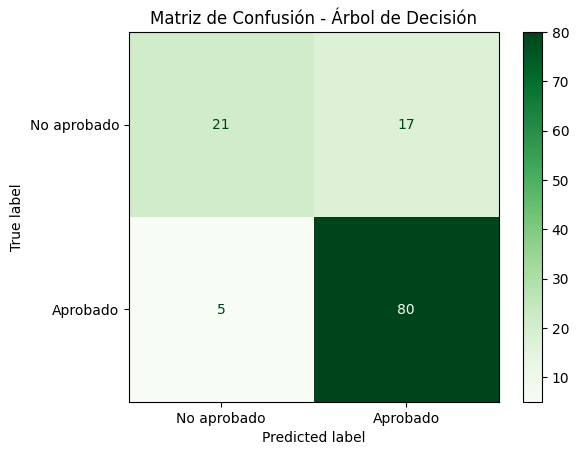

In [18]:
print("=== Árbol de Decisión ===")
print("Accuracy: ", accuracy_score(Y_test, Y_pred_dt))
print("Precision:", precision_score(Y_test, Y_pred_dt))
print("Recall:   ", recall_score(Y_test, Y_pred_dt))
print("F1-score: ", f1_score(Y_test, Y_pred_dt))

cm_dt = confusion_matrix(Y_test, Y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No aprobado','Aprobado'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

Importancia de variables (Árbol de Decisión):
Credit_History       0.686298
LoanAmount           0.120334
Education            0.053643
CoapplicantIncome    0.049138
ApplicantIncome      0.026494
Property_Area        0.024864
Loan_Amount_Term     0.020602
Dependents           0.018626
Gender               0.000000
Married              0.000000
Self_Employed        0.000000
dtype: float64


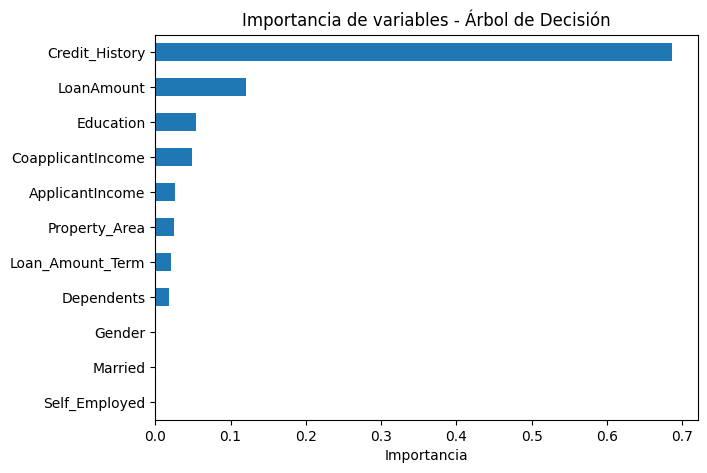

In [19]:
# Importancia de variables según el Árbol de Decisión
importancias = pd.Series(dt_model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia de variables (Árbol de Decisión):")
print(importancias)

plt.figure(figsize=(7,5))
importancias.plot(kind='barh')
plt.title('Importancia de variables - Árbol de Decisión')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.show()

### Interpretación.

Ambos modelos arrojan un buen desempeño, aunque lejos de ser perfecto. El modelo de regresión logistica obtuvo un Accuracy de 0.86, una precisión de  0.84, recall de 0.99 y F1 score de 0.91; el arbol de decisión obtuvo un accuracy de 0.84, precisión de 0.82, recall de 0.94 y F1 score de 0.88. 

La regresión logística superó ligeramente al arbol de decisión en todas las metricas.

A pesar de este desempeño se debe destacar que el recall es mucho mas alto que la precisión en ambos modelos, esto significa que el modelo es bueno detectando a los que si califican, sin embargo, aprueba solicitudes que no debían aprobarse. Para un banco o similar esto sería relevante porque aprobar a alguien que no debia aprobarse puede ser más costoso financieramente que rechazar a alguien que si calificaba.

¿Qué variable parece influir más en la predicción?

La variable más influyente es el historial crediticio (variable Credit_History) como se evidenció en la exploración de datos cuando observamos que todos los rechazos ocurrían en solicitantes sin historial.

¿Qué mejorarías si tuvieras más tiempo?

1. Recolectaría o construiría más variables, como la proporción entre el monto del credito y los ingresos totales del hogar. Sería más informativo que las variables por separado.
2. Realizar un ajuste hiperparametros usando gridsearchCV en vez de valores fijos elegidos manualmente.
3. Probar otro modelo como Random Forest.
